<a href="https://colab.research.google.com/github/kennedy-harris/mis433/blob/main/Copy_of_text_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Analytics

Text analytics turns unstructured language into data that can be counted, compared, visualized, and modeled. Unlike many tabular datasets, text is high-dimensional: a single column of comments, reviews, emails, or news articles can contain thousands of unique words, phrases, spellings, and meanings.

The main challenge is representation. Before we can summarize or model text, we need to decide how to convert language into numeric features while preserving enough meaning for the task. In this notebook, we will practice common steps in that workflow: cleaning and exploring text, converting text to document-term matrices, finding frequent words, measuring word importance with TF-IDF, clustering similar documents, creating word clouds, and estimating sentiment.

# Load and explore data from csv

Source: https://www.kaggle.com/datasets/cloudy17/bob-dylan-songs/

**Context**
This dataset contains songs from years between 1961 to 2020 written by Bob Dylan.

**Content**
There are 4 columns:
* release_year - year when song was released first time,
* album - name of the album where track occurs,
* title - title of the song,
* lyrics - lyrics of the track

In [1]:
import pandas as pd

# load dataset from csv
df = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/bob-dylan.csv')
df.head(3) # show the first three rows

,release_year,album,title,lyrics
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to..."
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ..."
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...


In [2]:
# shape of the df: rows and columns
df.shape

(345, 4)

In [3]:
# the data types of each column
df.dtypes

,0
release_year,int64
album,object
title,object
lyrics,object


In [4]:
# Get a summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   release_year  345 non-null    int64 
 1   album         345 non-null    object
 2   title         345 non-null    object
 3   lyrics        345 non-null    object
dtypes: int64(1), object(3)
memory usage: 10.9+ KB


In [5]:
# Count the values of a column
df.release_year.value_counts()

,count
release_year,
1975,30
1965,22
1963,22
1964,21
1970,19
1966,15
1967,13
1981,13
1983,13


In [6]:
df.album.value_counts()

,count
album,
"The Bootleg Series, Vol 1-3: Rare & Unreleased 1961-1991",37
The Basement Tapes,16
The Freewheelin',13
Blonde on Blonde,13
New Morning,12
John Wesley Harding,12
“Love and Theft”,12
Bringing It All Back Home,11
Under the Red Sky,10


In [7]:
# Add a new column
df['decade'] = (df['release_year'] // 10) * 10
df.head()

,release_year,album,title,lyrics,decade
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960


In [8]:
# String Operations
# Count the number of words in each song.

df['word_count'] = df['lyrics'].apply(lambda x: len(x.split()))
df.head()

,release_year,album,title,lyrics,decade,word_count
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960,353
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960,158
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960,391
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960,365
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960,477


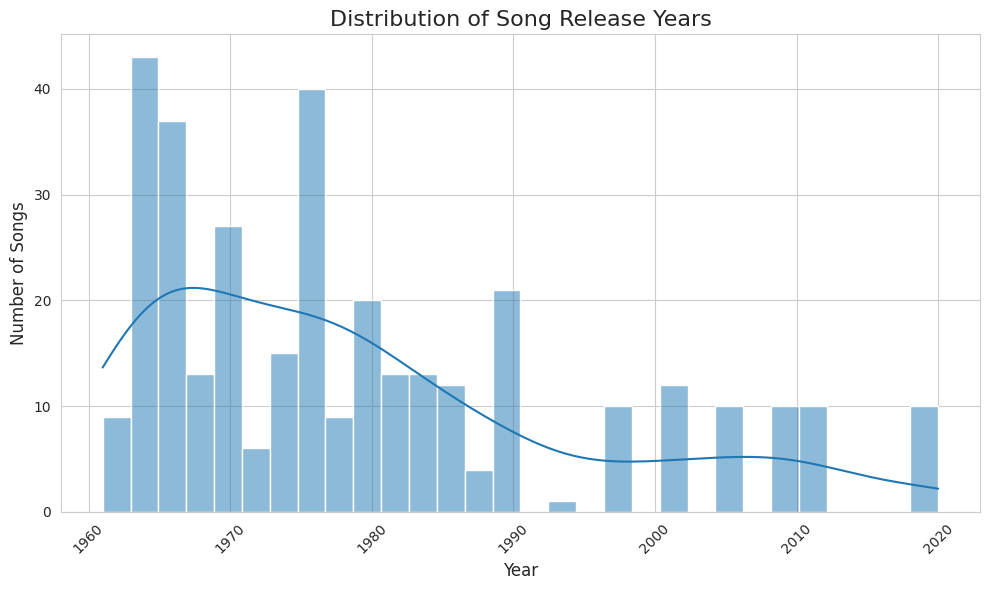

In [9]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # Set a prettier style

plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
sns.histplot(df['release_year'], bins=30, kde=True) # Use seaborn's histplot with kde for density estimate
plt.title('Distribution of Song Release Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## scikit-learn

Scikit-learn is one of the most popular Python packages for predictive data analysis. It includes tools for preprocessing text, building feature matrices, clustering documents, and training machine learning models.

https://scikit-learn.org/

If scikit-learn is not installed in your environment, uncomment and run the next cell.

In [ ]:
# !pip install scikit-learn

### Vectorization: Converting Text to Numeric Form

Text data must be converted into a numeric form before it can be used with machine learning algorithms. A common technique is `CountVectorizer`, which converts a collection of documents into a document-term matrix. Each row is a document, each column is a token, and each value is the number of times that token appears in that document.

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# Example using the 'lyrics' column of the Bob Dylan dataset
corpus = df['lyrics'].dropna().tolist()  # Assuming df is your DataFrame and dropping any missing values
vectorizer = CountVectorizer(stop_words='english')  # Remove common 'stop words'
X = vectorizer.fit_transform(corpus)

print(X.shape)  # Shows the shape of the matrix


(345, 7326)


In [11]:
# Accessing the Vocabulary
vocabulary = vectorizer.vocabulary_

# Print the vocabulary dictionary (word: column index)
print(vocabulary)

{'come': 1220, 'ladies': 3508, 'gentlemen': 2630, 'listen': 3691, 'song': 5938, 'sing': 5777, 'right': 5267, 'think': 6491, 'wrong': 7278, 'just': 3423, 'little': 3698, 'glimpse': 2681, 'story': 6172, 'll': 3707, 'tell': 6439, 'bout': 662, 'east': 1989, 'coast': 1182, 'city': 1111, 'know': 3492, 'hard': 2896, 'times': 6558, 'livin': 3704, 'new': 4247, 'york': 7313, 'town': 6627, 'old': 4352, 'friendly': 2531, 'washington': 7031, 'heights': 2981, 'harlem': 2902, 'mighty': 4008, 'people': 4601, 'millin': 4015, 'kick': 3443, 'knock': 3484, 'long': 3731, 'ways': 7056, 'golden': 2706, 'gate': 2605, 'rockefeller': 5321, 'plaza': 4741, 'empire': 2045, 'state': 6108, 'mister': 4055, 'sets': 5607, 'high': 3011, 'bird': 501, 'says': 5488, 'word': 7229, 'country': 1373, 'mornin': 4113, 'tryin': 6734, 'job': 3371, 'work': 7232, 'stand': 6079, 'place': 4706, 'till': 6552, 'feet': 2270, 'begin': 438, 'hurt': 3161, 'got': 2727, 'lot': 3760, 'money': 4084, 'make': 3847, 'merry': 3984, 'nickel': 4256, 

In [12]:
# Size of the vocabulary
len(vocabulary)

7326

In [13]:
# View the first document's feature vector
document_index = 0
feature_vector_sparse = X.getrow(document_index)

# To convert to a dense array
feature_vector_dense = feature_vector_sparse.toarray()

print(feature_vector_dense)

[[0 0 0 ... 0 0 0]]


In [14]:
# To View as a Readable Format

# Get feature names
feature_words = vectorizer.get_feature_names_out()

# Convert the sparse matrix row to a dense array
feature_vector_array = feature_vector_sparse.toarray().flatten()

# Create a dictionary mapping feature names to their values for the document
document_features = {feature_words[i]: int(feature_vector_array[i])
                     for i in range(len(feature_words)) if feature_vector_array[i] != 0}

print(document_features)

{'ay': 1, 'beat': 1, 'begin': 1, 'bird': 1, 'bit': 1, 'bought': 1, 'bout': 1, 'cal': 1, 'caves': 1, 'city': 9, 'cleaner': 1, 'coast': 1, 'come': 2, 'country': 1, 'dirt': 1, 'dream': 1, 'dust': 1, 'east': 1, 'empire': 2, 'feet': 2, 'ferry': 1, 'friendly': 1, 'gate': 1, 'gentlemen': 1, 'glimpse': 1, 'golden': 1, 'got': 2, 'hard': 7, 'harlem': 1, 'heights': 1, 'high': 1, 'hudson': 1, 'hurt': 1, 'island': 1, 'job': 1, 'just': 1, 'kick': 1, 'kind': 1, 'knock': 1, 'know': 1, 'ladies': 1, 'leave': 1, 'listen': 3, 'little': 1, 'livin': 7, 'll': 4, 'long': 1, 'lot': 1, 'make': 1, 'merry': 1, 'mighty': 2, 'millin': 1, 'mines': 1, 'minuet': 1, 'mister': 4, 'money': 1, 'mornin': 1, 'mountain': 1, 'ne': 1, 'new': 10, 'news': 1, 'newsy': 1, 'nickel': 1, 'oklahoma': 1, 'old': 4, 'paid': 1, 'people': 2, 'place': 1, 'plains': 1, 'plaza': 1, 'right': 2, 'rockefeller': 2, 'rocky': 1, 'sailin': 1, 'says': 1, 'sell': 1, 'sets': 1, 'sing': 1, 'smog': 1, 'song': 2, 'spread': 1, 'stand': 1, 'standin': 1, 'sta

In [15]:
# Getting the Most Frequent Words

import numpy as np

# Sum up the counts of each word across all documents
word_counts = np.sum(X.toarray(), axis=0)  # X is the result of vectorizer.fit_transform(corpus)

# Map from feature index to word
feature_words = vectorizer.get_feature_names_out()

# Combine counts and words into a dictionary, ensuring counts are Python integers
word_count_dict = {word: int(count) for word, count in zip(feature_words, word_counts)}

# Sort the dictionary by counts in descending order to get the most frequent words
sorted_word_count = sorted(word_count_dict.items(), key=lambda x: x[1], reverse=True)

# Print the top N most frequent words
top_n_words = 20  # You can adjust N as needed
print(sorted_word_count[:top_n_words])

[('don', 553), ('like', 496), ('just', 477), ('got', 465), ('ll', 451), ('know', 418), ('love', 301), ('gonna', 296), ('man', 287), ('time', 273), ('ve', 273), ('ain', 271), ('said', 265), ('come', 253), ('say', 252), ('oh', 241), ('tell', 219), ('baby', 207), ('way', 195), ('day', 192)]


/tmp/ipykernel_15021/531371955.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')


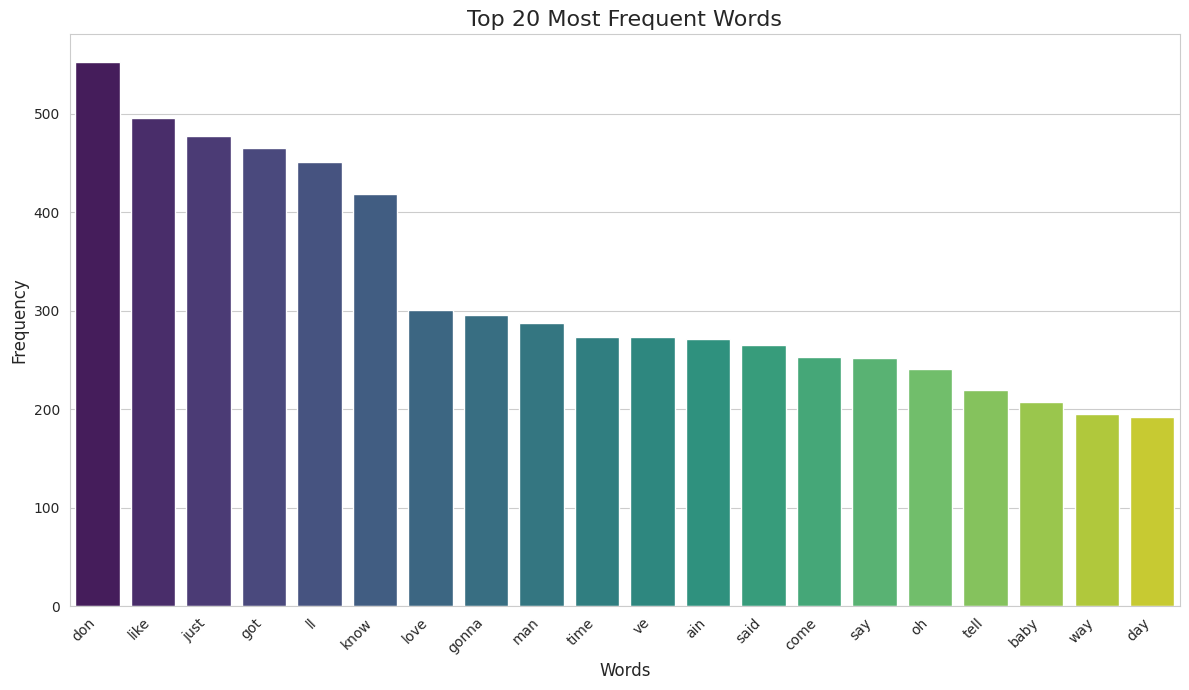

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract words and counts from the sorted_word_count list
words = [item[0] for item in sorted_word_count[:top_n_words]]
counts = [item[1] for item in sorted_word_count[:top_n_words]]

# Create a DataFrame for easier plotting with seaborn
most_frequent_words_df = pd.DataFrame({'Word': words, 'Count': counts})

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')
plt.title('Top 20 Most Frequent Words', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### TF-IDF: Weighing Word Importance

TF-IDF stands for term frequency-inverse document frequency. It gives higher scores to words that appear often in a particular document but not too often across the entire collection. This helps reduce the influence of common words and highlight words that are more distinctive for a song.

In practice, TF-IDF is often more useful than raw word counts for comparing documents because it balances local importance with overall rarity.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

print(X_tfidf.shape)


(345, 7326)


### Clustering: Grouping Similar Songs

With the numeric representations, you can now perform clustering to group similar songs.

**K-means** is a popular algorithm that can partition a set of data points into K groups, where K is predefined.

In [18]:
from sklearn.cluster import KMeans

# Using TF-IDF vectors for clustering
kmeans = KMeans(n_clusters=5, random_state=0)  # Assuming we want to cluster into 5 groups
kmeans.fit(X_tfidf)

# Print cluster labels for each song
print(kmeans.labels_)

# Count the number of songs in each cluster (from KMeans)
cluster_counts = np.bincount(kmeans.labels_)

print("KMeans Cluster Sizes:")
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count} songs")

[3 4 3 3 4 1 3 3 3 4 3 2 2 3 1 3 3 3 4 3 1 3 3 1 1 4 4 4 4 3 4 3 3 4 0 3 4
 1 1 0 1 3 3 3 3 1 0 3 1 4 3 3 1 3 2 1 3 3 3 3 3 3 4 0 1 3 4 1 1 1 3 1 4 3
 4 1 3 2 3 4 3 1 3 1 1 3 0 2 3 4 1 4 3 2 4 4 3 1 1 2 4 3 3 1 1 2 0 3 3 3 3
 4 4 0 4 4 3 3 3 2 0 3 0 4 4 0 1 1 2 3 3 0 3 3 3 3 1 3 0 3 1 1 3 2 3 3 1 2
 1 2 1 1 3 0 4 2 4 4 1 0 3 3 3 1 1 3 0 3 0 4 1 4 4 1 3 3 3 4 1 3 4 4 0 2 4
 3 4 2 4 0 1 3 3 1 4 1 3 1 3 1 3 1 1 0 4 3 1 1 3 1 4 1 3 2 1 0 2 3 1 1 1 0
 3 3 4 1 3 3 0 3 3 3 0 2 3 2 1 3 1 3 1 1 4 3 4 3 1 1 1 3 2 3 3 3 0 3 0 4 1
 3 3 3 1 4 1 1 1 3 4 4 3 3 4 3 3 3 1 3 3 4 3 0 4 3 3 3 3 3 2 3 3 2 3 3 3 3
 3 3 3 4 3 1 3 3 3 3 3 3 1 3 1 1 3 1 3 1 2 1 3 3 3 3 1 1 3 3 3 3 3 2 3 4 3
 1 1 1 4 2 3 3 3 3 3 2 3]
KMeans Cluster Sizes:
Cluster 0: 26 songs
Cluster 1: 82 songs
Cluster 2: 27 songs
Cluster 3: 154 songs
Cluster 4: 56 songs


**Hierarchical Clustering** is a different algorithm that agglomeratively groups similar objects into clusters, eventually forming a tree (hierarchy) of clusters.

Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):


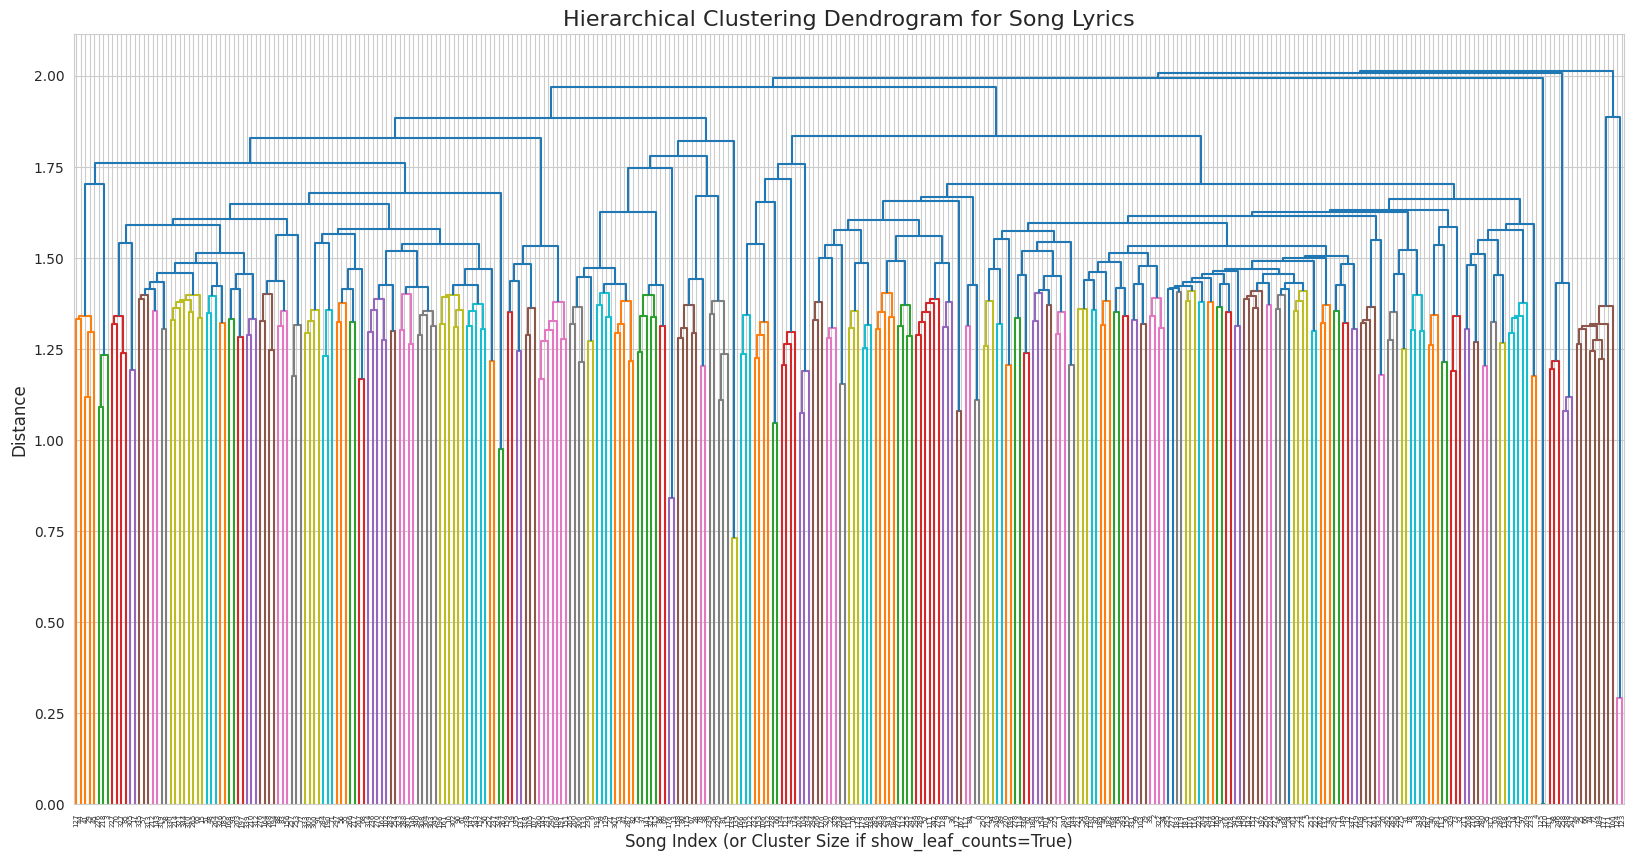

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

print("Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):")

# Perform hierarchical clustering on the TF-IDF vectors
# 'ward' linkage minimizes the variance of the clusters being merged.
# You can choose other methods like 'complete', 'average', 'single'.
linked = linkage(X_tfidf.toarray(), 'ward')

# Plot the dendrogram
plt.figure(figsize=(20, 10))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram for Song Lyrics', fontsize=16)
plt.xlabel('Song Index (or Cluster Size if show_leaf_counts=True)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.show()

### Create a Word Cloud

A word cloud is a quick visual summary of common words. It is easy to read, but it should be treated as exploratory rather than analytical because it does not show exact counts or account for context.

In [20]:
# Install wordcloud package
!pip install --upgrade wordcloud

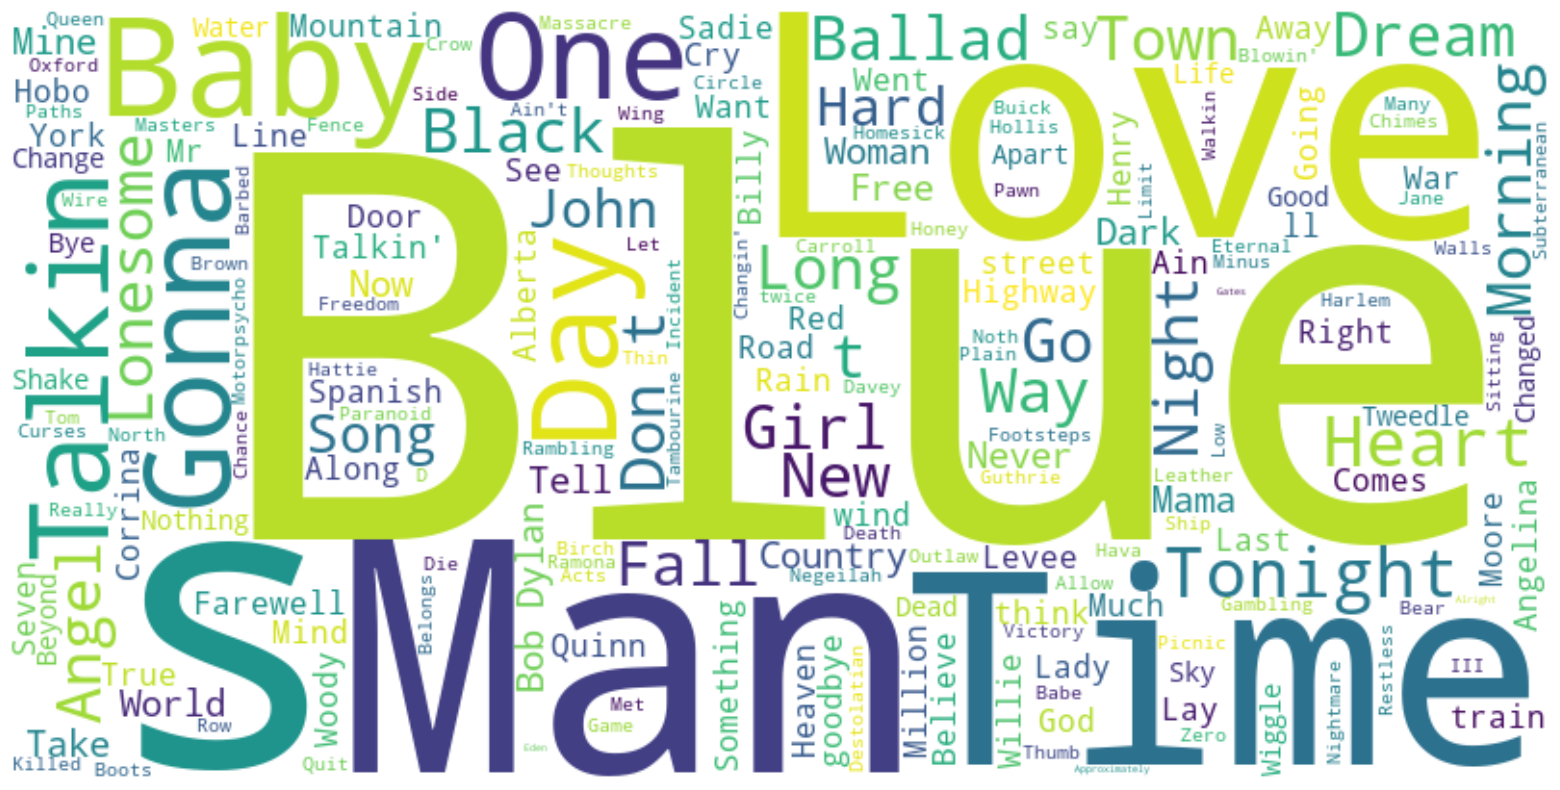

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all the text in the 'title' column into a single string
all_titles_text = " ".join(title for title in df['title'])

# Generate a word cloud image
wordcloud = WordCloud(background_color='white', width=800, height=400).generate(all_titles_text)

# Display the generated image
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


### Sentiment Analysis with a Pre-trained Model

For a simple sentiment analysis, you can use a pre-trained model from libraries such as TextBlob to estimate the sentiment score expressed in text.

TextBlob: https://textblob.readthedocs.io/en/dev/

In [21]:
# Install TextBlob
!pip install textblob

In [22]:
# This example uses TextBlob for sentiment analysis
from textblob import TextBlob

# Sample usage with the first five song's lyrics
for i in range(5):
    title = df['title'].iloc[i]
    lyrics = df['lyrics'].iloc[i]
    blob = TextBlob(lyrics)
    score = blob.sentiment.polarity
    print(f"{title}\t{lyrics[:25]}...\t{score}")

Hard Times In New York Town	Come you ladies and you g...	0.011896504729838058
Man on the street	’ll sing you a song, ain’...	-0.0692063492063492
Talkin’ Bear Mountain Picnic Massacre Blues	I saw it advertised one d...	0.14592111592111595
Let Me Die in My Footsteps	I will not go down under ...	-0.04433742183742184
Rambling, Gambling Willie	Come around you rovin’ ga...	-0.014664989664989669


## Exercises

Try these exercises to practice adapting the workflow above. Start by writing the code yourself, then compare your result with a partner or instructor.

In [23]:
# Exercise 1: Find the top 10 frequent words in Dylan's songs for each decade.
# Hint: loop through text_df.groupby('decade'), then fit a CountVectorizer to each decade's lyrics.

from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd

# Group the DataFrame by 'decade'
decades_grouped = df.groupby('decade')

# Iterate through each decade group
for decade, decade_df in decades_grouped:
    print(f"\n--- Decade: {decade}s ---")

    # Extract lyrics for the current decade and drop any missing values
    decade_corpus = decade_df['lyrics'].dropna().tolist()

    if not decade_corpus:
        print("No lyrics available for this decade.")
        continue

    # Initialize a CountVectorizer for the current decade
    # Using stop_words='english' to remove common words
    decade_vectorizer = CountVectorizer(stop_words='english')

    # Fit and transform the lyrics to get the document-term matrix for the decade
    X_decade = decade_vectorizer.fit_transform(decade_corpus)

    # Sum the counts of each word across all songs in the decade
    word_counts_decade = np.sum(X_decade.toarray(), axis=0)

    # Get the feature names (words) for this decade
    feature_words_decade = decade_vectorizer.get_feature_names_out()

    # Create a dictionary of word counts for the decade
    word_count_dict_decade = {word: int(count) for word, count in zip(feature_words_decade, word_counts_decade)}

    # Sort the words by their counts in descending order
    sorted_word_count_decade = sorted(word_count_dict_decade.items(), key=lambda x: x[1], reverse=True)

    # Print the top 10 most frequent words for the current decade
    top_n_words = 10
    print(f"Top {top_n_words} most frequent words:")
    for word, count in sorted_word_count_decade[:top_n_words]:
        print(f"  - {word}: {count}")


--- Decade: 1960s ---
Top 10 most frequent words:
  - just: 182
  - don: 152
  - like: 142
  - ll: 138
  - got: 135
  - ain: 127
  - know: 126
  - said: 103
  - come: 88
  - man: 84

--- Decade: 1970s ---
Top 10 most frequent words:
  - like: 146
  - don: 140
  - gonna: 125
  - just: 113
  - said: 98
  - know: 94
  - ll: 91
  - oh: 90
  - time: 89
  - got: 85

--- Decade: 1980s ---
Top 10 most frequent words:
  - don: 135
  - got: 110
  - know: 105
  - like: 97
  - just: 96
  - love: 87
  - man: 67
  - time: 64
  - ll: 60
  - baby: 59

--- Decade: 1990s ---
Top 10 most frequent words:
  - wiggle: 55
  - like: 42
  - don: 36
  - got: 31
  - god: 28
  - know: 27
  - til: 27
  - just: 26
  - knows: 22
  - gonna: 21

--- Decade: 2000s ---
Top 10 most frequent words:
  - got: 77
  - don: 57
  - ll: 52
  - gonna: 51
  - just: 44
  - know: 44
  - day: 41
  - say: 41
  - ain: 39
  - good: 39

--- Decade: 2010s ---
Top 10 most frequent words:
  - ll: 44
  - long: 32
  - blowin: 22
  - work: 22

In [ ]:
# Exercise 2: Create a boxplot showing sentiment scores across decades.
# Hint: use x='decade' and y='sentiment_polarity' with sns.boxplot().


In [24]:
from textblob import TextBlob

# Calculate sentiment polarity for each song and store it in a new column
df['sentiment_polarity'] = df['lyrics'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

/tmp/ipykernel_15021/469841593.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='sentiment_polarity', data=df, palette='viridis')


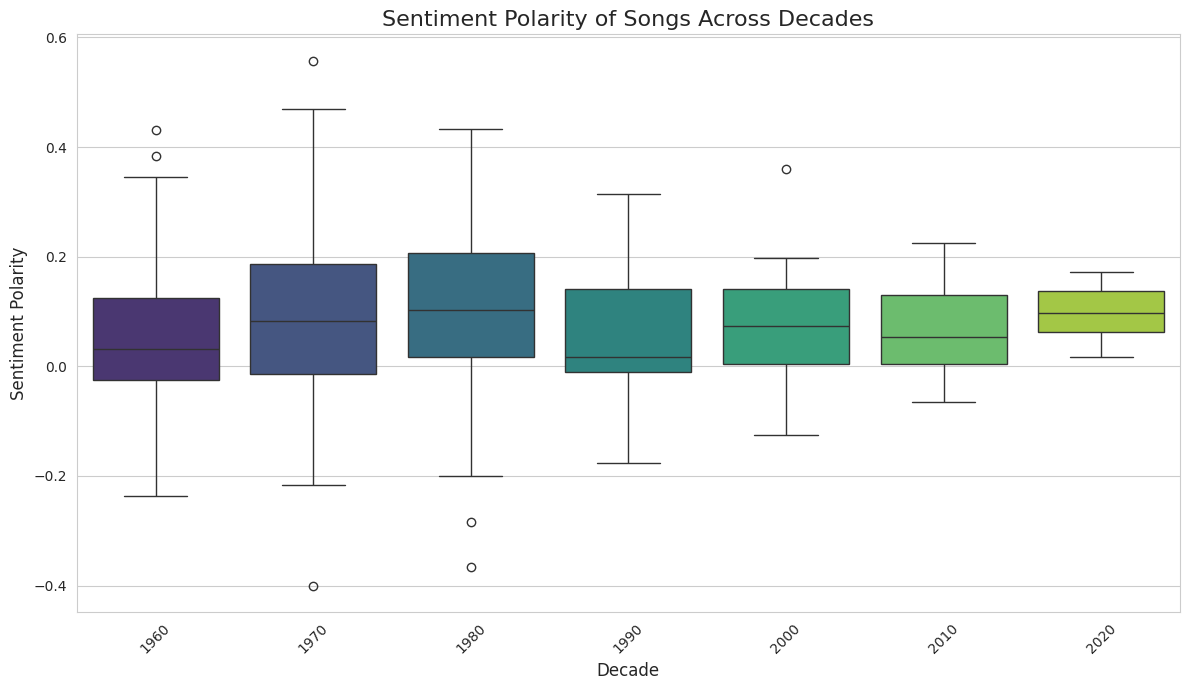

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize=(12, 7))
sns.boxplot(x='decade', y='sentiment_polarity', data=df, palette='viridis')
plt.title('Sentiment Polarity of Songs Across Decades', fontsize=16)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Sentiment Polarity', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Working with Text Data from an API

Many API responses contain text data. For instance, the [NewsAPI](https://newsapi.org/) searches articles and breaking-news headlines from news sources and blogs across the web.

In this section, we will search recent news articles and convert the results into a DataFrame for text analysis.

To use the NewsAPI, you'll need an API key. It's recommended to store your API key securely in Colab's secrets manager under the "🔑" icon in the left panel. Name the secret `NEWS_API_KEY`.

In [26]:
from google.colab import userdata

NEWS_API_KEY = userdata.get('NEWS_API_KEY')
print(f"API Key: {NEWS_API_KEY}")

API Key: 4ac94620a0a843549513590fdff981b5


In [27]:
import datetime

# Get today's date
today = datetime.date.today()

# Calculate the date three days ago
three_days_ago = today - datetime.timedelta(days=3)

# Format the date for the API request (YYYY-MM-DD)
from_param = three_days_ago.strftime('%Y-%m-%d')

print(f"Fetching news from: {from_param} to {today.strftime('%Y-%m-%d')}")

Fetching news from: 2026-05-24 to 2026-05-27


In [33]:
import requests
import pandas as pd # Import pandas for DataFrame

query = input("Please enter your search query for news articles: ")
print(f"Searching for articles related to: {query}")

# NewsAPI endpoint for all articles
url = 'https://newsapi.org/v2/everything'

# Parameters for the request
params = {
    'pageSize': 100,    # Max number of articles to retrieve per request for 'everything' endpoint
    'apiKey': NEWS_API_KEY,
    'q': query, # The search query
    'from': from_param, # Start date for the search (already calculated)
    'to': today.strftime('%Y-%m-%d'), # End date for the search (today)
    'language': 'en' # Filter for English language articles
}

try:
    response = requests.get(url, params=params)
    response.raise_for_status() # Raise an exception for HTTP errors
    data = response.json()

    print("Successfully fetched news articles.")

    articles_data = []
    for article in data['articles']:
        source_name = article.get('source', {}).get('name', 'N/A')
        articles_data.append({
            'title': article.get('title'),
            'author': article.get('author'),
            'source': source_name,
            'description': article.get('description'),
            'date': article.get('publishedAt')
        })

    news_df = pd.DataFrame(articles_data)

    print(f"Total articles retrieved and saved to DataFrame: {len(news_df)}")
    print(f"Total results matching query (available from API): {data['totalResults']}")
    display(news_df.head())

except requests.exceptions.RequestException as e:
    print(f"Error fetching news: {e}")
    if response.status_code == 401:
        print("Unauthorized: Check your API key.")
    elif response.status_code == 429:
        print("Too Many Requests: You may have hit your API rate limit.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Please enter your search query for news articles: dogs
Searching for articles related to: dogs
Successfully fetched news articles.
Total articles retrieved and saved to DataFrame: 94
Total results matching query (available from API): 338


,title,author,source,description,date
0,What Dogs See When They Look at Us,Adam Gopnik,The New Yorker,A humane study of how artists have captured ou...,2026-05-25T10:00:00Z
1,"Sea lions play ""pufferball""with unfortunate fish",Gail Sherman,Boing Boing,"Sea lions are the adorable dogs of the ocean, ...",2026-05-25T18:40:20Z
2,The Best Movies to Stream This Month (May 2026),Matt Kamen,Wired,"‘Bugonia,’ ‘Good Boy,’ and ‘Send Help’ are amo...",2026-05-26T20:29:54Z
3,Ice-cream-obsessed senior dog proves that the ...,Jennifer Sandlin,Boing Boing,A sweet ice-cream-obsessed senior dog is givin...,2026-05-25T18:30:26Z
4,Scientists say house cats could help unlock ne...,None,Science Daily,Scientists have cracked open the “black box” o...,2026-05-24T12:35:15Z


### Analyze the Text in the News Articles

What questions can we ask about this dataset?

- Which words appear most often in article titles or descriptions?
- Do different sources use different language for the same topic?
- How does sentiment vary across articles or sources?
- Are there clusters of articles that focus on different subtopics?

In [34]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd

# Combine title and description into a single text column
news_df['combined_text'] = news_df['title'].fillna('') + ' ' + news_df['description'].fillna('')

# Prepare the corpus for vectorization, ensuring no empty strings after combination
news_corpus = news_df['combined_text'].tolist()
news_corpus = [text for text in news_corpus if text.strip() != '']

# Initialize CountVectorizer to remove common English stop words
vectorizer_news = CountVectorizer(stop_words='english')

# Fit and transform the combined text data
X_news = vectorizer_news.fit_transform(news_corpus)

# Sum up the counts of each word across all documents
word_counts_news = np.sum(X_news.toarray(), axis=0)

# Get feature names (words)
feature_words_news = vectorizer_news.get_feature_names_out()

# Create a dictionary of word counts
word_count_dict_news = {word: int(count) for word, count in zip(feature_words_news, word_counts_news)}

# Sort the words by their counts in descending order
sorted_word_count_news = sorted(word_count_dict_news.items(), key=lambda x: x[1], reverse=True)

# Print the top 10 most frequent words
top_n_words_news = 10
print(f"Top {top_n_words_news} most frequent words in article titles and descriptions:")
for word, count in sorted_word_count_news[:top_n_words_news]:
    print(f"  - {word}: {count}")

Top 10 most frequent words in article titles and descriptions:
  - dogs: 38
  - dog: 33
  - new: 15
  - appeared: 14
  - post: 14
  - twistedsifter: 12
  - cats: 11
  - just: 11
  - love: 11
  - pet: 10


In [35]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Group the news DataFrame by 'source'
sources_grouped = news_df.groupby('source')

# Iterate through each source group
for source_name, source_df in sources_grouped:
    print(f"\n--- Source: {source_name} ---")

    # Extract combined text for the current source, ensuring no NaNs
    source_corpus = source_df['combined_text'].dropna().tolist()

    if not source_corpus:
        print("No articles available for this source.")
        continue

    # Initialize a CountVectorizer for the current source
    source_vectorizer = CountVectorizer(stop_words='english')

    # Fit and transform the text to get the document-term matrix
    X_source = source_vectorizer.fit_transform(source_corpus)

    # Sum the counts of each word across all articles from this source
    word_counts_source = np.sum(X_source.toarray(), axis=0)

    # Get the feature names (words) for this source
    feature_words_source = source_vectorizer.get_feature_names_out()

    # Create a dictionary of word counts for the source
    word_count_dict_source = {word: int(count) for word, count in zip(feature_words_source, word_counts_source)}

    # Sort the words by their counts in descending order
    sorted_word_count_source = sorted(word_count_dict_source.items(), key=lambda x: x[1], reverse=True)

    # Print the top 10 most frequent words for the current source
    top_n_words_source = 10
    print(f"Top {top_n_words_source} most frequent words:")
    for word, count in sorted_word_count_source[:top_n_words_source]:
        print(f"  - {word}: {count}")


--- Source: 24/7 Wall St. ---
Top 10 most frequent words:
  - ai: 3
  - 500: 2
  - infrastructure: 2
  - boom: 1
  - collapses: 1
  - earnings: 1
  - energy: 1
  - forward: 1
  - growing: 1
  - growth: 1

--- Source: ABC News (AU) ---
Top 10 most frequent words:
  - dog: 3
  - cafe: 2
  - committee: 2
  - complaint: 2
  - friendly: 2
  - greyhound: 2
  - phase: 2
  - racing: 2
  - review: 2
  - tasmania: 2

--- Source: Acecomments.mu.nu ---
Top 10 most frequent words:
  - article: 1
  - assault: 1
  - believers: 1
  - claiming: 1
  - clownish: 1
  - disappear: 1
  - dogs: 1
  - dredge: 1
  - encompassing: 1
  - entirely: 1

--- Source: Activistpost.com ---
Top 10 most frequent words:
  - israel: 2
  - saying: 2
  - blood: 1
  - captives: 1
  - continue: 1
  - control: 1
  - days: 1
  - foley: 1
  - freakout: 1
  - israeli: 1

--- Source: Android Authority ---
Top 10 most frequent words:
  - steam: 3
  - android: 2
  - deck: 2
  - handheld: 2
  - valve: 2
  - allowed: 1
  - app: 1
  - 

Sentiment Polarity Statistics by Source:
                     count      mean       std       min       25%       50%  \
source                                                                         
24/7 Wall St.          1.0 -0.049107       NaN -0.049107 -0.049107 -0.049107   
ABC News (AU)          3.0  0.151705  0.216034 -0.056250  0.040057  0.136364   
Acecomments.mu.nu      1.0 -0.060000       NaN -0.060000 -0.060000 -0.060000   
Activistpost.com       1.0  0.005682       NaN  0.005682  0.005682  0.005682   
Android Authority      1.0  0.195833       NaN  0.195833  0.195833  0.195833   
...                    ...       ...       ...       ...       ...       ...   
Writersdigest.com      1.0  0.139286       NaN  0.139286  0.139286  0.139286   
Yahoo Entertainment    1.0  1.000000       NaN  1.000000  1.000000  1.000000   
allears.net            2.0  0.200000  0.424264 -0.100000  0.050000  0.200000   
disneyfoodblog.com     2.0  0.316250  0.061550  0.272727  0.294489  0.316250   

/tmp/ipykernel_15021/1586928237.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='source', y='sentiment_polarity', data=news_df, palette='coolwarm')


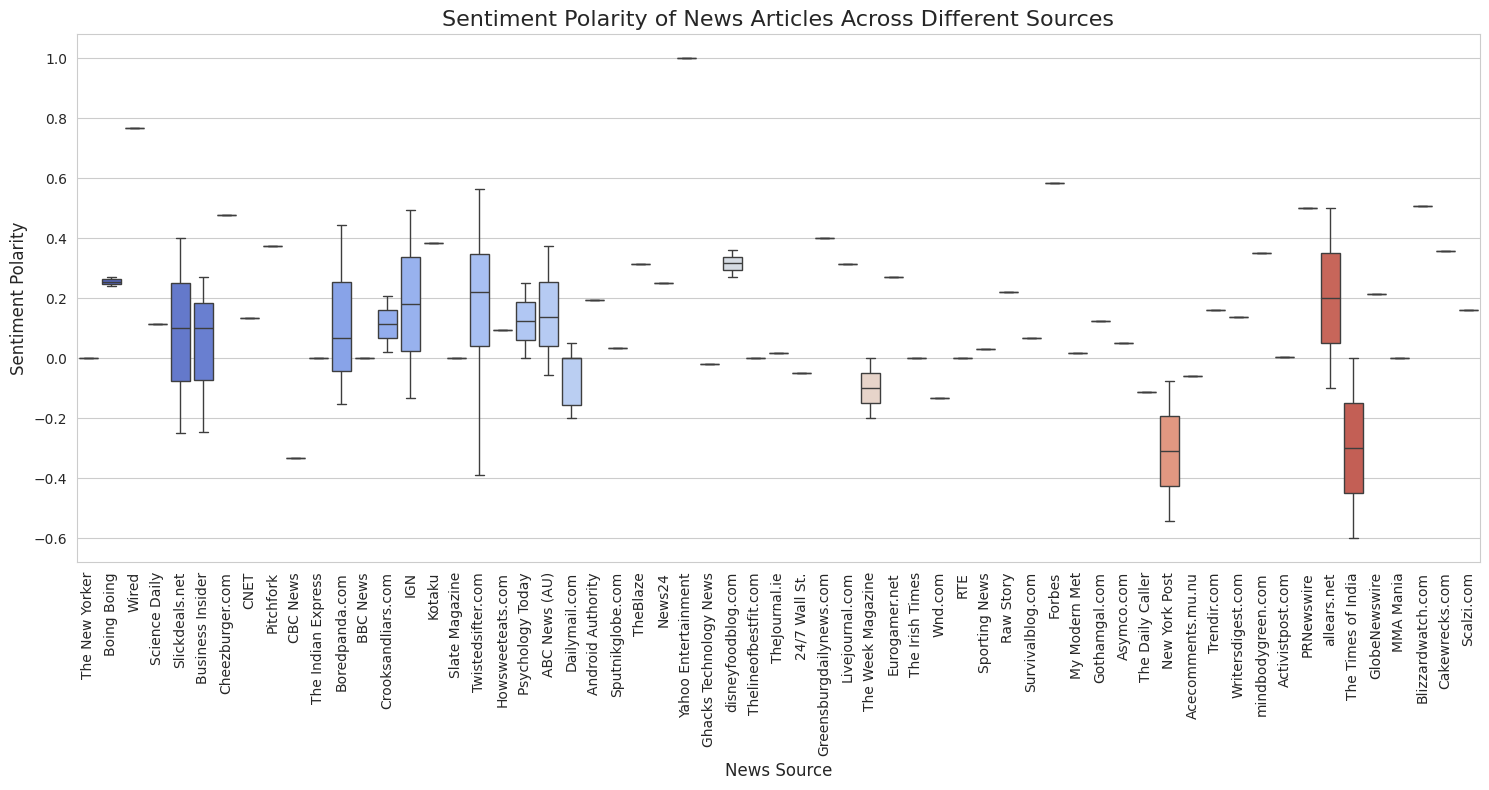

In [36]:
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate sentiment polarity for each article's combined text
news_df['sentiment_polarity'] = news_df['combined_text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Display descriptive statistics of sentiment polarity by source
sentiment_by_source = news_df.groupby('source')['sentiment_polarity'].describe()
print("Sentiment Polarity Statistics by Source:")
print(sentiment_by_source)

# Create a boxplot to visualize sentiment distribution across sources
plt.figure(figsize=(15, 8))
sns.boxplot(x='source', y='sentiment_polarity', data=news_df, palette='coolwarm')
plt.title('Sentiment Polarity of News Articles Across Different Sources', fontsize=16)
plt.xlabel('News Source', fontsize=12)
plt.ylabel('Sentiment Polarity', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

# Ensure 'combined_text' column exists and handle potential NaN values
news_df['combined_text'] = news_df['title'].fillna('') + ' ' + news_df['description'].fillna('')
news_corpus = news_df['combined_text'].tolist()
news_corpus = [text for text in news_corpus if text.strip() != '']

# Initialize TF-IDF Vectorizer
tfidf_vectorizer_news = TfidfVectorizer(stop_words='english', max_features=1000) # Limit features for manageability
X_tfidf_news = tfidf_vectorizer_news.fit_transform(news_corpus)

# Determine an appropriate number of clusters (e.g., 3 to 5 clusters seems reasonable for subtopics)
n_clusters = 5
kmeans_news = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init for robust centroid initialization
kmeans_news.fit(X_tfidf_news)

# Assign cluster labels back to the DataFrame
news_df_clustered = news_df.copy()
# Map original DataFrame indices to corpus indices, then assign cluster labels
# This assumes the order of news_corpus directly corresponds to non-empty combined_text entries in news_df
# A more robust approach might be to filter news_df first then apply clustering, or map labels carefully.
# For simplicity, we'll create a new column and fill based on current corpus order.
cluster_labels = np.full(len(news_df_clustered), -1) # Initialize with -1 for articles not in corpus
corpus_indices = [i for i, text in enumerate(news_df['combined_text'].tolist()) if text.strip() != '']

for original_idx, corpus_idx in enumerate(news_df.index):
    if news_df.loc[corpus_idx, 'combined_text'].strip() != '':
        try:
            # Find the position of this article in the filtered news_corpus
            pos_in_corpus = [i for i, x in enumerate(news_df_clustered.loc[news_df_clustered['combined_text'].apply(lambda s: s.strip() != '')].index) if x == corpus_idx][0]
            cluster_labels[original_idx] = kmeans_news.labels_[pos_in_corpus]
        except IndexError:
            # This case should ideally not happen if news_corpus is built correctly from news_df
            pass
news_df_clustered['cluster_label'] = cluster_labels



print(f"K-Means Clustering performed with {n_clusters} clusters.")
print("Cluster distribution:")
print(news_df_clustered['cluster_label'].value_counts().sort_index())

# Function to get top words for each cluster
def get_top_words_for_clusters(model, vectorizer, num_words=10):
    feature_names = vectorizer.get_feature_names_out()
    print(f"\nTop {num_words} words per cluster:")
    for i, centroid in enumerate(model.cluster_centers_):
        top_words_indices = centroid.argsort()[::-1][:num_words]
        top_words = [feature_names[j] for j in top_words_indices]
        print(f"Cluster {i}: {', '.join(top_words)}")

# Print top words for each cluster
get_top_words_for_clusters(kmeans_news, tfidf_vectorizer_news)

# Display some articles from each cluster to get a sense of subtopics
print("\nSample articles from each cluster:")
for i in range(n_clusters):
    print(f"\n--- Cluster {i} Articles ---")
    sample_articles = news_df_clustered[news_df_clustered['cluster_label'] == i]['title'].sample(min(3, len(news_df_clustered[news_df_clustered['cluster_label'] == i]))) # take max 3 samples
    for title in sample_articles:
        print(f"- {title}")

K-Means Clustering performed with 5 clusters.
Cluster distribution:
cluster_label
0     5
1    47
2    30
3     5
4     7
Name: count, dtype: int64

Top 10 words per cluster:
Cluster 0: artist, art, towel, tiny, great, feel, matter, interesting, makes, help
Cluster 1: dogs, time, 2026, love, cats, amazon, pet, new, ai, used
Cluster 2: dog, appeared, day, post, twistedsifter, trump, trust, dogs, owners, owner
Cluster 3: met, 30c, forecast, éireann, hit, temperatures, memes, according, dividend, animal
Cluster 4: disney, world, magic, chips, review, sold, trick, favorite, new, 007

Sample articles from each cluster:

--- Cluster 0 Articles ---
- Giant Great Dane Realizes He Has to Share His Bed With a Tiny New Puppy—and His Face Says It All
- Inside the secret art of hotel towel twisting: Artist reveals how she makes fluffy crocodiles, frogs, dogs and tiny bunnies for guests
- The Queue: Fine Art

--- Cluster 1 Articles ---
- 'The Swiss mandatory training tried to teach our sleepy dogs m